In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline



In [6]:
df = pd.read_csv(r"C:\Users\jaisw\OneDrive\Documents\Sample_ Superstore.csv")

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.shape

(9994, 19)

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Ship Date     9994 non-null   object 
 4   Ship Mode     9994 non-null   object 
 5   Customer ID   9994 non-null   object 
 6   Segment       9994 non-null   object 
 7   Country       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null 

# Observation 
Dataset rows and columns number are displayed and observed that the dataset contains both numerical and categorical variables.

In [11]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [12]:
df.duplicated().sum()

0

# Observation
The dataset contains no null values like we can see and also 0 duplicates.


In [14]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
df.mean(numeric_only=True)

Row ID      4997.500000
Sales        229.858001
Quantity       3.789574
Discount       0.156203
Profit        28.656896
dtype: float64

In [16]:
df.median(numeric_only=True)

Row ID      4997.5000
Sales         54.4900
Quantity       3.0000
Discount       0.2000
Profit         8.6665
dtype: float64

In [17]:
df.mode().iloc[0]

Row ID                        1
Order ID         CA-2017-100111
Order Date           09-05-2016
Ship Date            12/16/2015
Ship Mode        Standard Class
Customer ID            WB-21850
Segment                Consumer
Country           United States
City              New York City
State                California
Region                     West
Product ID      OFF-PA-10001970
Category        Office Supplies
Sub-Category            Binders
Product Name    Staple envelope
Sales                     12.96
Quantity                    3.0
Discount                    0.0
Profit                      0.0
Name: 0, dtype: object

In [18]:
df.std(numeric_only=True)

Row ID      2885.163629
Sales        623.245101
Quantity       2.225110
Discount       0.206452
Profit       234.260108
dtype: float64

# Observation
The statistics here summarizes thedistribution of numerical values in the dataset, including Sales, Quantity, Discount, and Profit.

In [21]:
df["Order Date"].head(10)

0    11-08-2016
1    11-08-2016
2    06-12-2016
3    10-11-2015
4    10-11-2015
5    06-09-2014
6    06-09-2014
7    06-09-2014
8    06-09-2014
9    06-09-2014
Name: Order Date, dtype: object

In [23]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed")

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Ship Date     9994 non-null   datetime64[ns]
 4   Ship Mode     9994 non-null   object        
 5   Customer ID   9994 non-null   object        
 6   Segment       9994 non-null   object        
 7   Country       9994 non-null   object        
 8   City          9994 non-null   object        
 9   State         9994 non-null   object        
 10  Region        9994 non-null   object        
 11  Product ID    9994 non-null   object        
 12  Category      9994 non-null   object        
 13  Sub-Category  9994 non-null   object        
 14  Product Name  9994 non-null   object        
 15  Sales         9994 non-null   float64 

# Observation 
Converted date from text to date format for python to perform date based analysis of sales trend.

In [25]:
df["Month"] = df["Order Date"].dt.to_period("M")
df["Quarter"] = df["Order Date"].dt.to_period("Q")

In [26]:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

# Observation
Calculated the monthly sales for Plot and Graphs to analyze sales growth.

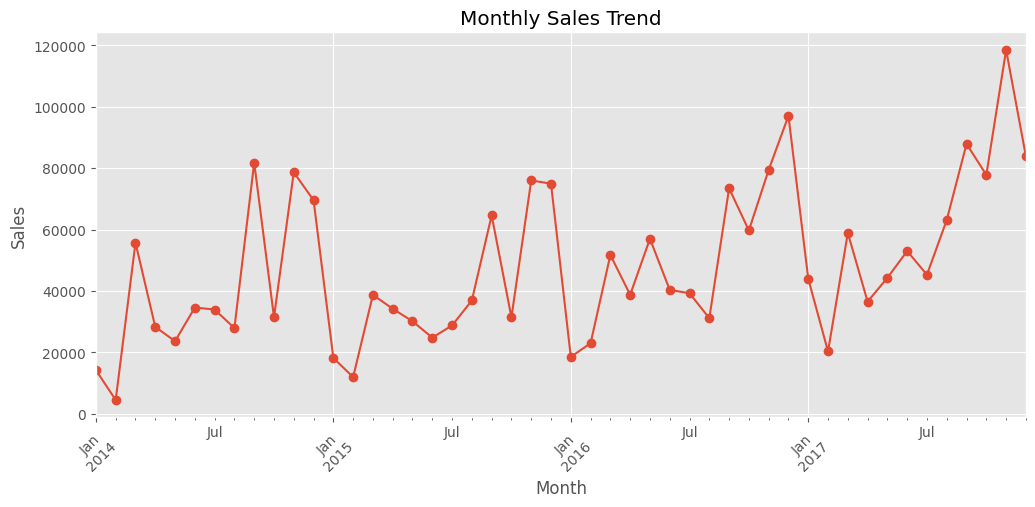

In [27]:
monthly_sales.plot(figsize=(12,5), marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# Obseravtion- Monthly Sales Trend
We can see that the monthly sales fluctuate significantly for over four year time period in accordance to the customer demand. 
Along with that the highest sales can be seen at the end of 2017 showing business Growth.

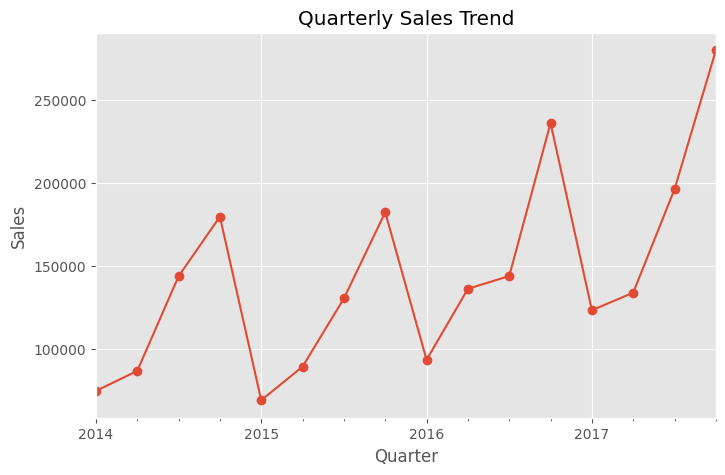

In [28]:
quarterly_sales = df.groupby("Quarter")["Sales"].sum()

quarterly_sales.plot(figsize=(8,5), marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

# Observation- Quaterly Sales Trend
Quaterly sales also shows an over all increasing trend from 2014 to 2017 indicating good business growth.
We can observe that sales fluctuate across quarters, suggesting timely season demand and can be customer purchasing patterns that during end on the year light purchase or waiting for new years offers.

In [29]:
segment_count = df["Segment"].value_counts()
segment_count

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

# Observation
Segment count for customer segment analysis.

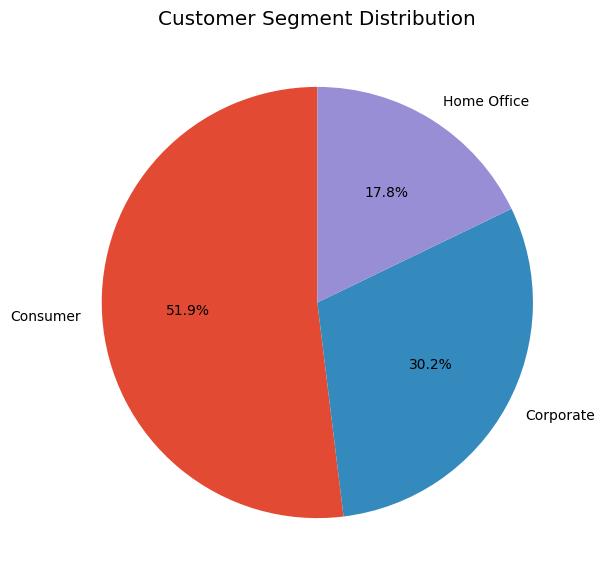

In [32]:
plt.figure(figsize=(7,7))

segment_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Customer Segment Distribution")

plt.show()

# Observation- Customer Segment Distribution
We can see that the consumer segment contributes the largest share of orders indicating they are the highest sales 
And corporate segment represents the second- largest customer group with 30.2% indicating significant contribution
Lastly thehome Office segments has the smallest number of orders. The overall observation shows that the compny should invest more on the customer segment as they are generating the highest sales.

In [33]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

# Observation
Calculating the top 10 products for there graphical representation.

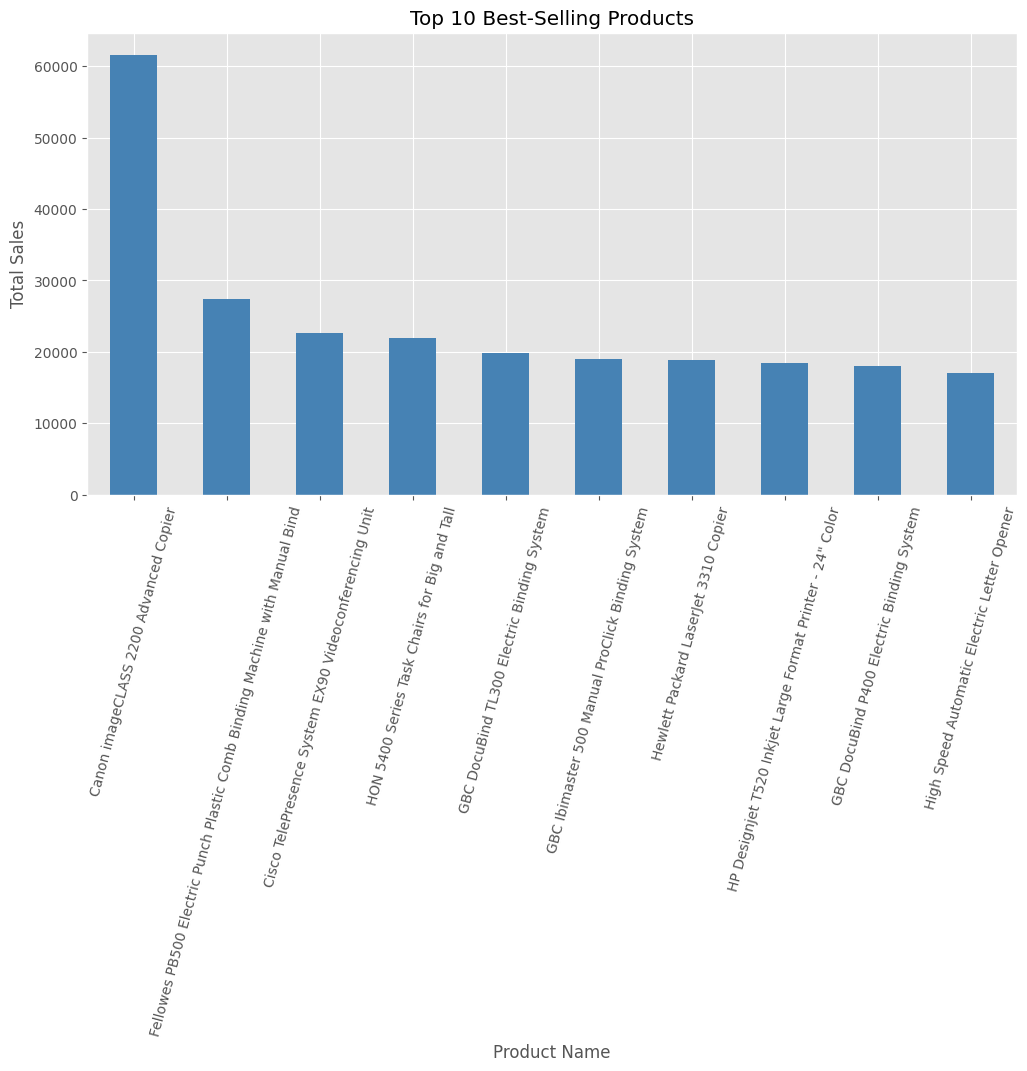

In [34]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar", color="steelblue")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)

plt.show()

# Observation - Top 10 best selling products
The Canon imageCLASS 2200 Advanced Copier is the highest-selling product, generating over $60,000 in total sales outperforming all other products.

The sales among a few products suggests that these items contribute substantially to the company's overall revenue and should be prioritized for inventory management and promotional campaigns.


In [35]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

# Observation
Products with there revenue.

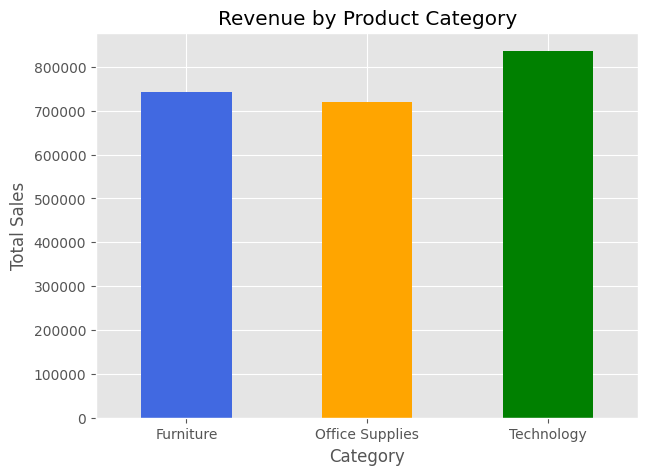

In [36]:
plt.figure(figsize=(7,5))

category_sales.plot(kind="bar", color=["royalblue","orange","green"])

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

# Observation - Revenue By Product Category
We can see that technology generates the highest revenue among all product categories also furniture is the second highest revenue generating product and well office supplies are the least revenue generating product.
It helps to decide that the investment needs to be proritized for technology 
and furniture products as they are more revenue generating.

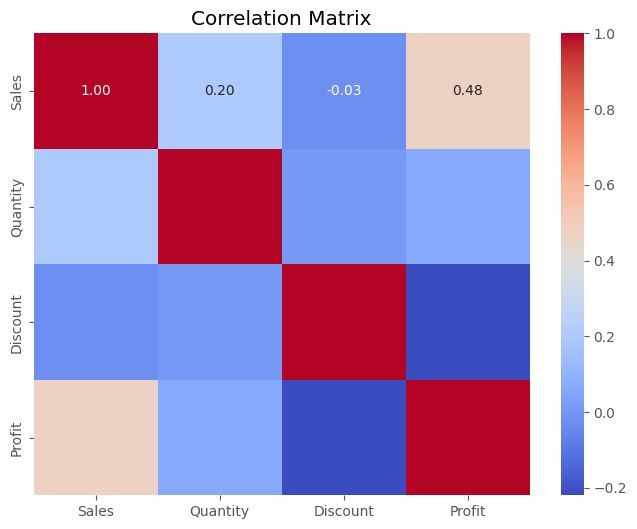

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# Observation- Correlation Matrix

Sales and Profit show a positive correlation, indicating that higher sales generate higher profits.
Discount has a weak negative correlation with Profit, showing that larger  reduce profitability.
Quantity has only a weak relationship with Sales and Profit, showing that higher order quantities do not always translate into higher revenue or profit.


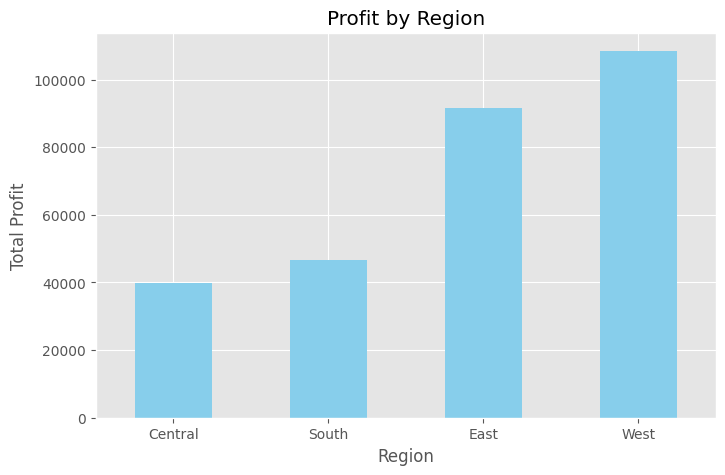

In [38]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values()

plt.figure(figsize=(8,5))
region_profit.plot(kind="bar", color="skyblue")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

# Observation - Profit by Region (Additional Visualization)
We can observe that profit varies significantly across different regions.
The west region here generates the highest overall profit, while east generating second highest indicating where the expansion of business can benefit.
Similarly the lowest profit generating region is central and second lowest in south it shows that some measures and strategies needs to be implemented in these regions in order to generate more profit from tese regions and improve customer satisfaction.



# Conclusion - Business Recommendations 
After overall analysis I observe what are the top profit generating products what sectors exactly contribures highest in the business and which factors are affecting the profits that is discount and also which regions are the most revenue generating regions.
1. Focused should me more on inventory and promotional efforts on top- selling products like Canon imageCLASS 2200 Advanced Copier and other high-performing technology products.
2. All the schemes and strategies needs to be studied and analyzed thoroughly since the higher discounts are showing negatice profits not helping in the business growth so it should be targeted rather that just offered randomly.
3. Sales strategies used in high performing regions like west East those strategies needs to be expanded to low performing regions like central to improve sales and profitability in these lower performing regions.